In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import math
import random
from tqdm.notebook import tqdm as tqdm
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches

In [2]:
device="cpu" 

In [3]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [4]:
def sin(t):
    return np.sin(t)

def saw(t):
    return ( ((t-np.pi)/(2*np.pi))%1 - .5) *2

def square(t):
    return np.sign(np.sin(t))

def tri(t):
    sw = saw(t+np.pi/2)*2
    return sw * np.sign(sw)- 1

In [5]:
def create_waveforms(fn=sin, fs=512, duration=1024, period=440, phase=0, amplitude=1):
    period = np.array(period)
    period = np.reshape(period, (period.size, 1))

    phase = np.array(phase)
    phase = np.reshape(phase, (phase.size, 1))

    amplitude = np.array(amplitude)
    amplitude = np.reshape(amplitude, (amplitude.size, 1))

    t = (np.arange(0, duration, 1)/fs)[None,:]
    x = amplitude * fn(2*np.pi*(phase + t*period))
    return x, t

In [6]:
class VAE(torch.nn.Module):
    def __init__(self, input_dim=512, latent_dim=2, hidden_dims=[128, 64, 36]):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1],hidden_dims[2]),
            torch.nn.Tanh(),
            
        )

        self.z_mean = torch.nn.Linear(hidden_dims[2], latent_dim)
        self.z_log_var = torch.nn.Linear(hidden_dims[2], latent_dim)


        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dims[2]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[2], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1], hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], input_dim),
        )


    def reparameterize(self, z_mu, z_log_var):
        device = z_mu.device
        # Sampling the eps from the standard multivariate normal distribution in each forward pass
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(device)
        # reparameterized_mean = mean_vector + random noise(eps) + log variance
        z = z_mu + eps * torch.exp(z_log_var / 2.0)
        return z

    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded,z_mean,z_log_var,decoded

In [7]:
input_length = 256

np.random.seed(0)
n_samples_train = 100000

periods_train = np.random.uniform(200, 2000, n_samples_train)

x_sin, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=periods_train[0*n_samples_train//4:1*n_samples_train//4], amplitude=1)
x_saw, _ = create_waveforms(fn=saw, fs=22050, duration=input_length, phase=0, period=periods_train[1*n_samples_train//4:2*n_samples_train//4], amplitude=1)
x_tri, _ = create_waveforms(fn=tri, fs=22050, duration=input_length, phase=0, period=periods_train[2*n_samples_train//4:3*n_samples_train//4], amplitude=1)
x_square, _ = create_waveforms(fn=square, fs=22050, duration=input_length, phase=0, period=periods_train[3*n_samples_train//4:4*n_samples_train//4], amplitude=1)

x_train = torch.tensor(np.concatenate([x_sin, x_saw, x_tri, x_square], axis=0), dtype=torch.float32)
shapes_train = np.arange(n_samples_train) // (n_samples_train//4)

In [8]:
AE = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
AE.load_state_dict(torch.load("beta_zero.pth"))
good_VAE = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
good_VAE.load_state_dict(torch.load("beta_zerooneeight.pth"))
BAE = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
BAE.load_state_dict(torch.load("beta_zerotwo.pth"))

<All keys matched successfully>

In [9]:
shuffle_indices = np.random.permutation(np.arange(n_samples_train))

x_train_shuffle = x_train[shuffle_indices]
shapes_train_shuffle = shapes_train[shuffle_indices]
periods_train_shuffle = periods_train[shuffle_indices]

In [10]:
x = AE.encoder(x_train_shuffle)
z_mean, z_log_var = AE.z_mean(x), AE.z_log_var(x)
AE_encoded_orig = AE.reparameterize(z_mean, z_log_var).detach().numpy()

In [11]:
x = good_VAE.encoder(x_train_shuffle)
z_mean, z_log_var = good_VAE.z_mean(x), good_VAE.z_log_var(x)
good_AE_encoded_orig = good_VAE.reparameterize(z_mean, z_log_var).detach().numpy()

In [12]:
x = BAE.encoder(x_train_shuffle)
z_mean, z_log_var = BAE.z_mean(x), BAE.z_log_var(x)
BAE_encoded_orig = BAE.reparameterize(z_mean, z_log_var).detach().numpy()

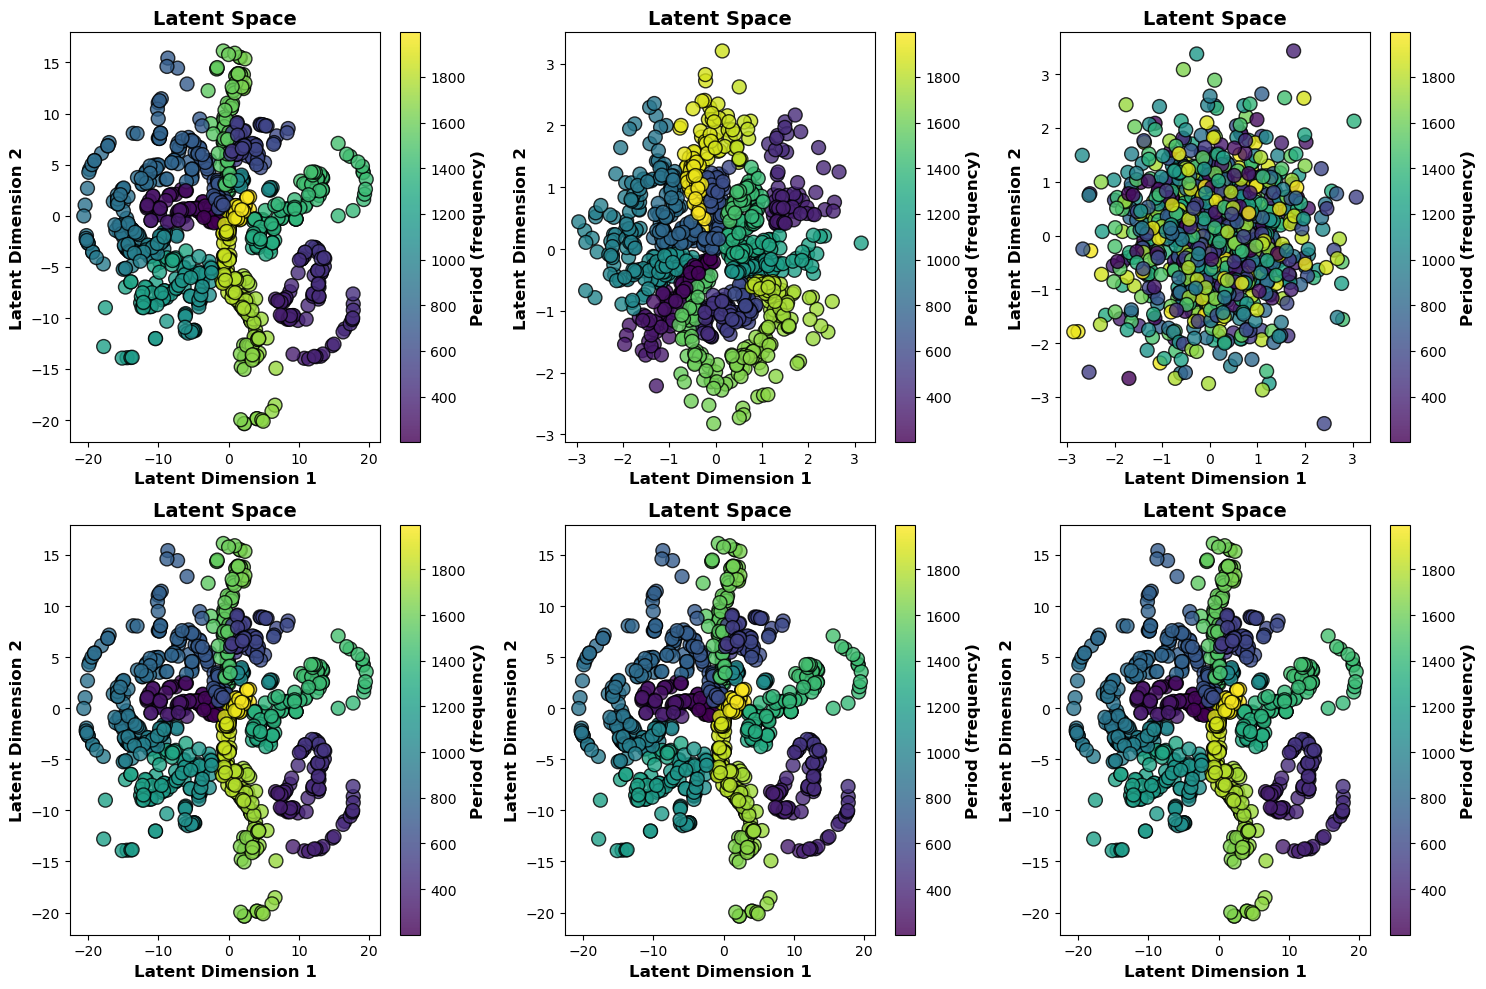

In [13]:
cmap = 'viridis'
n_plot=1000

# Create a 2x3 grid (6 subplots)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Function to create the scatter plot with color bar, allowing different encoded_orig
def create_scatter(ax, encoded_orig):
    scatter = ax.scatter(encoded_orig[:n_plot, 0], encoded_orig[:n_plot, 1], 
                         c=periods_train_shuffle[:n_plot], cmap=cmap, alpha=0.8, 
                         edgecolors='k', s=100, marker='o')

    ax.set_xlabel("Latent Dimension 1", fontsize=12, fontweight='bold')
    ax.set_ylabel("Latent Dimension 2", fontsize=12, fontweight='bold')
    ax.set_title("Latent Space", fontsize=14, fontweight='bold')

    # Add color bar to this specific plot
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Period (frequency)', fontsize=12, fontweight='bold')

create_scatter(axes[0, 0], AE_encoded_orig)
create_scatter(axes[0, 1], good_AE_encoded_orig)
create_scatter(axes[0, 2], BAE_encoded_orig)
create_scatter(axes[1, 0], AE_encoded_orig)
create_scatter(axes[1, 1], AE_encoded_orig)
create_scatter(axes[1, 2], AE_encoded_orig)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Show the complete figure
plt.show()

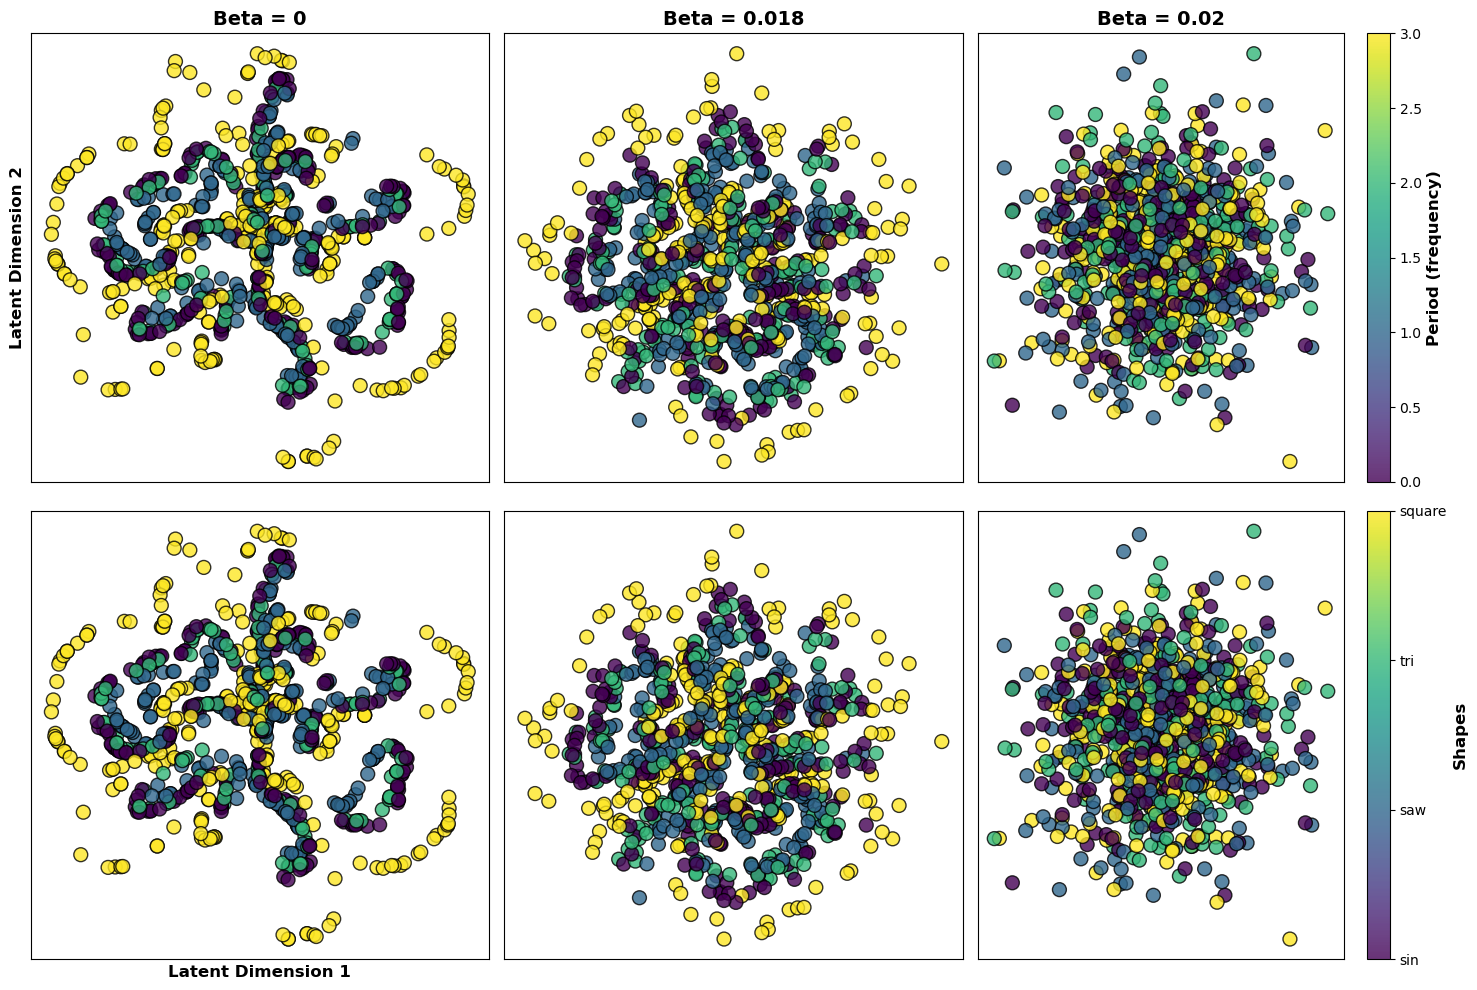

In [14]:
n_plot=1000
cmap = 'viridis'

# Create a 2x3 grid (6 subplots)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Function to create the scatter plot with an optional color bar and custom encoded_orig and periods_train_shuffle
def create_scatter(ax, encoded_orig, periods_train_shuffle, add_colorbar=False,character = "frequency"):
    scatter = ax.scatter(encoded_orig[:n_plot, 0], encoded_orig[:n_plot, 1], 
                         c=periods_train_shuffle[:n_plot], cmap=cmap, alpha=0.8, 
                         edgecolors='k', s=100, marker='o')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.set_yticks([])

    # Add color bar only if required (first plot in each row)
    if add_colorbar:
        if character == "shape":
            cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1, 2, 3])
            cbar.ax.set_yticklabels(["sin", "saw", "tri", "square"])
            cbar.set_label('Shapes', fontsize=12, fontweight='bold')
        else:
            cbar = fig.colorbar(scatter, ax=ax)
            cbar.set_label('Period (frequency)', fontsize=12, fontweight='bold')


# Create scatter plots for the first row (with a color bar only for the first plot)
create_scatter(axes[0, 0], AE_encoded_orig, periods_train_shuffle)
create_scatter(axes[0, 1], good_AE_encoded_orig, periods_train_shuffle)
create_scatter(axes[0, 2], BAE_encoded_orig, periods_train_shuffle,add_colorbar=True)

# Create scatter plots for the second row (with a color bar only for the first plot)
create_scatter(axes[1, 0], AE_encoded_orig, shapes_train_shuffle,character="shape")
create_scatter(axes[1, 1], good_AE_encoded_orig, shapes_train_shuffle,character="shape")
create_scatter(axes[1, 2], BAE_encoded_orig, shapes_train_shuffle,add_colorbar=True,character="shape")

# Remove axes labels and ticks for all except the first plot in each row
# for row in range(2):
#     for col in range(1, 3):  # For columns 1 and 2 (skip the first column)
#         axes[row, col].set_xticks([])
#         axes[row, col].set_yticks([])
#         axes[row, col].set_xlabel('')
#         axes[row, col].set_ylabel('')

# Add axis labels only to the first plot in each row
# axes[0, 0].set_xlabel("Latent Dimension 1", fontsize=12, fontweight='bold')
# axes[0, 0].set_ylabel("Latent Dimension 2", fontsize=12, fontweight='bold')
axes[0, 0].set_title("Beta = 0", fontsize=14, fontweight='bold')
axes[0, 1].set_title("Beta = 0.018", fontsize=14, fontweight='bold')
axes[0, 2].set_title("Beta = 0.02", fontsize=14, fontweight='bold')

# axes[0, 0].set_xlabel('')
# axes[0, 0].set_xticks([])
# axes[0, 1].set_xlabel('')
# axes[0, 1].set_xticks([])
# axes[0, 2].set_xlabel('')
# axes[0, 2].set_xticks([])

# axes[0, 1].set_ylabel('')
# axes[0, 1].set_yticks([])
# axes[0, 2].set_ylabel('')
# axes[0, 2].set_yticks([])

# axes[1, 1].set_ylabel('')
# axes[1, 1].set_yticks([])
# axes[1, 2].set_ylabel('')
# axes[1, 2].set_yticks([])

axes[1, 0].set_xlabel("Latent Dimension 1", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Latent Dimension 2", fontsize=12, fontweight='bold')



# Adjust layout to prevent overlapping elements
plt.tight_layout()
plt.savefig(r"Latent dimensions.png")
# Show the complete figure
plt.show()


In [15]:
BAE_encoded_orig.shape

(100000, 2)